In [1]:
!pip install --pre pycaret[full]

  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached uvicorn-0.38.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached typer-0.20.0-py3-none-any.whl.metadata (16 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of dash-bootstrap-components to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of dash-bootstrap-components to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions o

In [1]:
import pycaret
from pycaret.regression import *
from pycaret.datasets import get_data
import pandas as pd 
import numpy as np 

In [2]:
bst = get_data('boston')

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
setup(data= bst,target='medv',session_id =123)

,Description,Value
0,Session id,123
1,Target,medv
2,Target type,Regression
3,Original data shape,"(506, 14)"
4,Transformed data shape,"(506, 14)"
5,Transformed train set shape,"(354, 14)"
6,Transformed test set shape,"(152, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [6]:
bm = compare_models(
    n_select=3,           # Select top 3 models instead of all
    fold=3,               # Use 3-fold CV instead of default 10-fold
    round=2,              # Round results to 2 decimal places
    verbose=True          # Show progress
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.19,10.26,3.19,0.88,0.14,0.11,0.07
gbr,Gradient Boosting Regressor,2.30,10.54,3.24,0.88,0.15,0.12,0.06
catboost,CatBoost Regressor,2.10,10.17,3.18,0.88,0.14,0.11,0.82
rf,Random Forest Regressor,2.32,11.04,3.32,0.87,0.15,0.12,0.08
lightgbm,Light Gradient Boosting Machine,2.49,13.64,3.65,0.84,0.16,0.12,17.19
xgboost,Extreme Gradient Boosting,2.59,14.86,3.85,0.83,0.17,0.13,0.06
ada,AdaBoost Regressor,2.86,15.95,3.98,0.81,0.18,0.15,0.05
ridge,Ridge Regression,3.27,22.51,4.72,0.74,0.27,0.16,0.01
dt,Decision Tree Regressor,3.15,22.72,4.69,0.74,0.22,0.16,0.02
lr,Linear Regression,3.30,22.39,4.71,0.74,0.25,0.17,0.02


In [26]:
cb = create_model('catboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.2919,9.6775,3.1109,0.8917,0.1208,0.0868
1,1.6188,4.4207,2.1025,0.9045,0.1041,0.0854
2,2.2188,8.2327,2.8693,0.9178,0.1541,0.1300
3,2.5955,20.0783,4.4809,0.8020,0.1761,0.1313
4,1.7785,6.0625,2.4622,0.9486,0.1273,0.0922
5,1.8834,6.9000,2.6268,0.8716,0.1389,0.1028
6,1.8945,7.0188,2.6493,0.8960,0.1351,0.0976
7,2.4925,21.0920,4.5926,0.8065,0.1576,0.1058
8,1.8299,5.6321,2.3732,0.8993,0.1364,0.1079


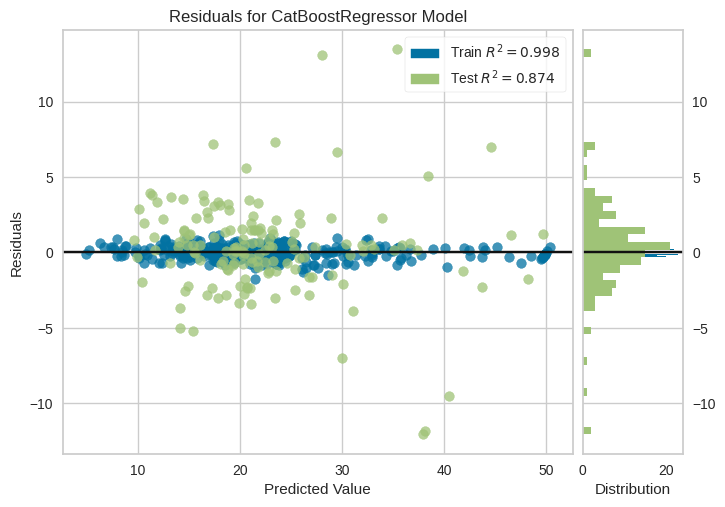

In [27]:
plot_model(cb)

In [28]:
evaluate_model(cb)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

TypeError: CatBoostRegressor.predict() missing 1 required positional argument: 'data'